In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Data\Processed_nassau_candy_data.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Units,Gross Profit,Cost,Lead_Time,Profit_Margin,Revenue_Per_Unit,Unit_Cost,Factory,Factory_Latitude,Factory_Longitude
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,2,4.22,2.28,8,0.649231,3.25,1.14,Wicked Choccy's,32.076176,-81.088371
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,2,4.90,2.60,8,0.653333,3.75,1.30,Wicked Choccy's,32.076176,-81.088371
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3,7.47,3.00,8,0.713467,3.49,1.00,Lot's O' Nuts,32.881893,-111.768036
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3,7.50,3.30,8,0.694444,3.60,1.10,Lot's O' Nuts,32.881893,-111.768036
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,3,7.35,3.90,7,0.653333,3.75,1.30,Wicked Choccy's,32.076176,-81.088371


In [4]:
factory_performance = (
    df.groupby("Factory")
    .agg({
        "Lead_Time":"mean",
        "Gross Profit":"sum",
        "Sales":"sum"
    })
    .round(2)
)

print(factory_performance)

                   Lead_Time  Gross Profit     Sales
Factory                                             
Lot's O' Nuts           6.74      52771.05  76340.15
Secret Factory          6.44       4344.70   8587.50
Sugar Shack             6.61        121.23    220.98
The Other Factory       6.49        152.25   1282.25
Wicked Choccy's         6.82      36053.57  55352.75


In [5]:
factory_leadtime = (
    df.groupby("Factory")["Lead_Time"]
    .mean()
)

best_factory = factory_leadtime.idxmin()

print("Recommended Factory:")
print(best_factory)

Recommended Factory:
Secret Factory


In [6]:
scenario = (
    df.groupby(["Factory","Ship Mode"])
    ["Lead_Time"]
    .mean()
)

print(scenario.head())

Factory         Ship Mode     
Lot's O' Nuts   First Class       3.998876
                Same Day          3.045902
                Second Class      6.048214
                Standard Class    8.025170
Secret Factory  First Class       3.957447
Name: Lead_Time, dtype: float64


In [7]:
profit_by_factory = (
    df.groupby("Factory")["Gross Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(profit_by_factory)

Factory
Lot's O' Nuts        52771.05
Wicked Choccy's      36053.57
Secret Factory        4344.70
The Other Factory      152.25
Sugar Shack            121.23
Name: Gross Profit, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

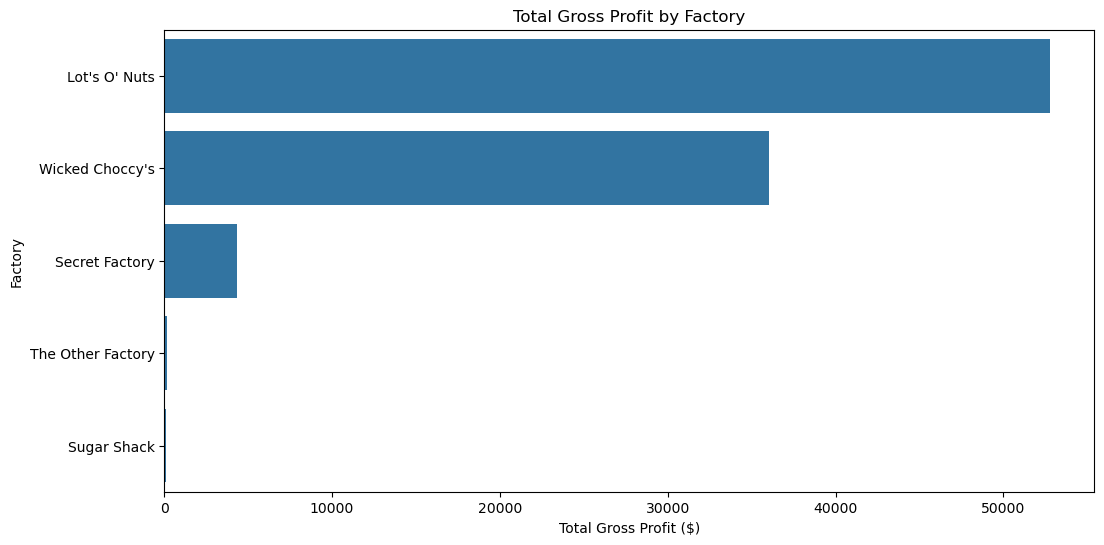

In [9]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=profit_by_factory.values,
    y=profit_by_factory.index
)

plt.title("Total Gross Profit by Factory")
plt.xlabel("Total Gross Profit ($)")
plt.ylabel("Factory")

plt.show()

In [10]:
best_profit_factory = profit_by_factory.idxmax()
best_profit_value = profit_by_factory.max()

print("MOST PROFITABLE FACTORY")
print(f"Factory: {best_profit_factory}")
print(f"Total Profit: ${best_profit_value:,.2f}")

MOST PROFITABLE FACTORY
Factory: Lot's O' Nuts
Total Profit: $52,771.05


In [11]:
factory_summary = (
    df.groupby("Factory")
    .agg({
        "Lead_Time":"mean",
        "Gross Profit":"sum",
        "Sales":"sum"
    })
    .round(2)
)

# Profit score (higher is better)
factory_summary["Profit_Score"] = (
    factory_summary["Gross Profit"]
    / factory_summary["Gross Profit"].max()
) * 100

# Lead time score (lower is better)
lead_min = factory_summary["Lead_Time"].min()
lead_max = factory_summary["Lead_Time"].max()

factory_summary["LeadTime_Score"] = (
    (lead_max - factory_summary["Lead_Time"])
    / (lead_max - lead_min)
) * 100

# Balanced score
factory_summary["Optimization_Score"] = (
    0.6 * factory_summary["Profit_Score"]
    +
    0.4 * factory_summary["LeadTime_Score"]
)

factory_summary = factory_summary.sort_values(
    "Optimization_Score",
    ascending=False
)

print(factory_summary)

                   Lead_Time  Gross Profit     Sales  Profit_Score  \
Factory                                                              
Lot's O' Nuts           6.74      52771.05  76340.15    100.000000   
Secret Factory          6.44       4344.70   8587.50      8.233113   
Wicked Choccy's         6.82      36053.57  55352.75     68.320736   
The Other Factory       6.49        152.25   1282.25      0.288510   
Sugar Shack             6.61        121.23    220.98      0.229728   

                   LeadTime_Score  Optimization_Score  
Factory                                                
Lot's O' Nuts           21.052632           68.421053  
Secret Factory         100.000000           44.939868  
Wicked Choccy's          0.000000           40.992442  
The Other Factory       86.842105           34.909948  
Sugar Shack             55.263158           22.243100  


In [12]:
best_factory = factory_summary.index[0]

print("RECOMMENDED FACTORY")
print(best_factory)

RECOMMENDED FACTORY
Lot's O' Nuts


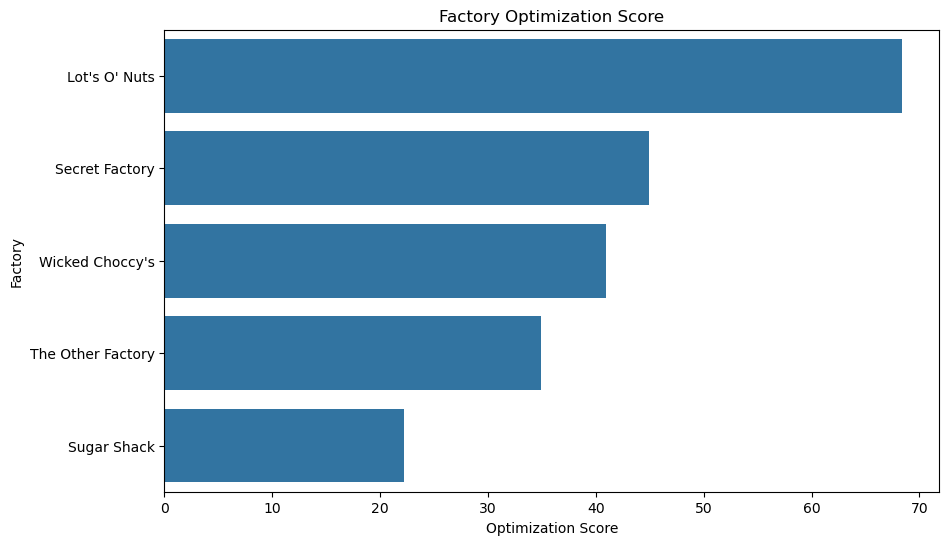

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=factory_summary.reset_index(),
    x="Optimization_Score",
    y="Factory"
)

plt.title("Factory Optimization Score")
plt.xlabel("Optimization Score")
plt.ylabel("Factory")

plt.show()

In [14]:
def simulate_scenario(
    factory,
    ship_mode,
    region,
    units
):

    avg_profit = df[
        (df["Factory"] == factory)
        &
        (df["Ship Mode"] == ship_mode)
        &
        (df["Region"] == region)
    ]["Gross Profit"].mean()

    avg_leadtime = df[
        (df["Factory"] == factory)
        &
        (df["Ship Mode"] == ship_mode)
        &
        (df["Region"] == region)
    ]["Lead_Time"].mean()

    expected_profit = avg_profit * units

    if avg_leadtime <= 4:
        recommendation = "Fast Delivery"
    elif avg_leadtime <= 7:
        recommendation = "Balanced Option"
    else:
        recommendation = "Slow but Economical"

    return {
    "Expected Profit": float(round(expected_profit, 2)),
    "Expected Lead Time": float(round(avg_leadtime, 2)),
    "Recommendation": recommendation
}

In [15]:
simulate_scenario(
    "Lot's O' Nuts",
    "First Class",
    "Atlantic",
    10
)

{'Expected Profit': 93.78,
 'Expected Lead Time': 3.0,
 'Recommendation': 'Fast Delivery'}

In [16]:
simulate_scenario(
    "Secret Factory",
    "Same Day",
    "Pacific",
    50
)

{'Expected Profit': 363.75,
 'Expected Lead Time': 4.0,
 'Recommendation': 'Fast Delivery'}

In [17]:
simulate_scenario(
    "Wicked Choccy's",
    "Standard Class",
    "Interior",
    100
)

{'Expected Profit': 850.21,
 'Expected Lead Time': 8.0,
 'Recommendation': 'Slow but Economical'}

In [18]:
simulate_scenario(
    "Lot's O' Nuts",
    "Second Class",
    "Gulf",
    200
)

{'Expected Profit': 1826.91,
 'Expected Lead Time': 6.0,
 'Recommendation': 'Balanced Option'}